In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.utils.dataframe_utils import create_dataframe

df_train_seg_0 = create_dataframe(
    "../data/train.csv", 
    "../data/boneage-training-segmented-gray", 
    segmented=True)

df_val_seg = create_dataframe(
    "../data/validation.csv",
    "../data/boneage-validation-segmented-gray", 
    segmented=True)



In [3]:
df_test_seg = create_dataframe(
    "../data/test.csv",
    "../data/boneage-test-segmented-gray", 
    segmented=True)

In [4]:
df_test_seg

,id,male,boneage,path
0,9727,False,120,../data/boneage-test-segmented-gray/9727_seg.png
1,9731,True,84,../data/boneage-test-segmented-gray/9731_seg.png
2,9743,False,113,../data/boneage-test-segmented-gray/9743_seg.png
3,9748,False,144,../data/boneage-test-segmented-gray/9748_seg.png
4,9755,False,106,../data/boneage-test-segmented-gray/9755_seg.png
...,...,...,...,...
620,15592,False,42,../data/boneage-test-segmented-gray/15592_seg.png
621,15601,False,132,../data/boneage-test-segmented-gray/15601_seg.png
622,15607,True,186,../data/boneage-test-segmented-gray/15607_seg.png
623,15611,False,120,../data/boneage-test-segmented-gray/15611_seg.png


In [5]:
from sklearn.preprocessing import StandardScaler

def scaling_data_torch(df, df_val):

    labels = df[["boneage"]].values.astype("float32")
    
    labels_val = df_val[["boneage"]].values.astype("float32")

    scaler = StandardScaler()
    scaler.fit(labels)

    df[["boneage"]] = scaler.transform(labels)
    df_val[["boneage"]]= scaler.transform(labels_val)

    return df, df_val, scaler

In [6]:
df_train_seg, df_val_seg, scaler_seg = scaling_data_torch(df_train_seg_0, df_val_seg)

In [7]:
def scale_only(df, scaler):
    df = df.copy()
    df[["boneage"]] = scaler.transform(df[["boneage"]].values.astype("float32"))
    return df

df_test_seg = scale_only(df_test_seg, scaler_seg)


In [8]:
df_test_seg

,id,male,boneage,path
0,9727,False,-0.177773,../data/boneage-test-segmented-gray/9727_seg.png
1,9731,True,-1.051975,../data/boneage-test-segmented-gray/9731_seg.png
2,9743,False,-0.347757,../data/boneage-test-segmented-gray/9743_seg.png
3,9748,False,0.405029,../data/boneage-test-segmented-gray/9748_seg.png
4,9755,False,-0.517740,../data/boneage-test-segmented-gray/9755_seg.png
...,...,...,...,...
620,15592,False,-2.071878,../data/boneage-test-segmented-gray/15592_seg.png
621,15601,False,0.113628,../data/boneage-test-segmented-gray/15601_seg.png
622,15607,True,1.424932,../data/boneage-test-segmented-gray/15607_seg.png
623,15611,False,-0.177773,../data/boneage-test-segmented-gray/15611_seg.png


In [9]:
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import torch

class BoneAgeDataset(Dataset):

    def __init__(self, df_seg, transform=None):

        self.df_seg = df_seg.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df_seg)

    def __getitem__(self, idx):

        row = self.df_seg.iloc[idx]

        # immagine originale
        image = Image.open(row["path"])

        if self.transform:
            image = self.transform(image)

        sample = {
            "image": image,
            "male": torch.tensor(float(row["male"]), dtype=torch.float32),
            "boneage": torch.tensor(float(row["boneage"]), dtype=torch.float32),
            "id": int(row["id"])
        }

        return sample

In [10]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = BoneAgeDataset(df_train_seg, transform=transform)
val_dataset = BoneAgeDataset(df_val_seg, transform=transform)

In [11]:
test_dataset = BoneAgeDataset(df_test_seg, transform=transform)

In [12]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [13]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [14]:
import time

print("=== TEST DATALOADER ===")

t0 = time.time()
batch = next(iter(train_loader))
t1 = time.time()

print("DataLoader time:", t1 - t0)

=== TEST DATALOADER ===
DataLoader time: 0.4628872871398926


In [15]:
import torch
import torch.nn as nn

class FiLM(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.gamma = nn.Linear(1, channels)
        self.beta = nn.Linear(1, channels)

    def forward(self, x, male):
        """
        x: [B, C, H, W]
        male: [B, 1]
        """

        gamma = self.gamma(male).unsqueeze(-1).unsqueeze(-1)
        beta = self.beta(male).unsqueeze(-1).unsqueeze(-1)

        return x * (1 + gamma) + beta

In [16]:
class CNNEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(1, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)   # [B, 256, H/16, W/16]

In [17]:
class BoneAgeModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = CNNEncoder()

        self.film = FiLM(256)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.regressor = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, image, male=None):

        x = self.encoder(image)   # [B, 256, H, W]

        if male is not None:
            x = self.film(x, male)

        x = self.pool(x)          # [B, 256, 1, 1]
        x = torch.flatten(x, 1)   # [B, 256]

        x = self.regressor(x)

        return x.squeeze(1)



In [18]:
device = torch.device("cuda")
model = BoneAgeModel().to(device)
print(model)

BoneAgeModel(
  (encoder): CNNEncoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU()
      (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): ReLU()
    )
  )
  (film): FiLM(
    (gamma): Linear(in_features=1, out_features=256, bias=True)
    (beta): Linear(in_features=1, out_features=256, bias=True)
  )
  (pool): AdaptiveAvgPool2d(out

In [19]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader

import numpy as np
import os
import copy
from tqdm import tqdm


# =========================
# EARLY STOPPING
# =========================

class EarlyStopping:

    def __init__(self, patience=10, min_delta=0.0):

        self.patience = patience
        self.min_delta = min_delta

        self.best_loss = np.inf
        self.counter = 0
        self.best_model = None

    def step(self, val_loss, model):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss
            self.counter = 0
            self.best_model = copy.deepcopy(model.state_dict())

            return True  # improvement

        else:
            self.counter += 1

            return False

    def should_stop(self):
        return self.counter >= self.patience


# =========================
# METRICS
# =========================

def mae_months(pred, target, scaler):

    # inverse transform (standardized → months)
    pred = pred * scaler.scale_[0] + scaler.mean_[0]
    target = target * scaler.scale_[0] + scaler.mean_[0]

    return torch.mean(torch.abs(pred - target)).item()


# =========================
# TRAIN ONE EPOCH
# =========================

def train_one_epoch(model, loader, optimizer, criterion, device, use_male=False):

    model.train()
    total_loss = 0.0

    for batch in tqdm(loader):

        image = batch["image"].to(device)
        y = batch["boneage"].float().to(device)

        if use_male:
            male = batch["male"].float().unsqueeze(1).to(device)
        else:
            male = None

        optimizer.zero_grad()

        pred = model(image, male=male)

        loss = criterion(pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


# =========================
# VALIDATION
# =========================

def validate(model, loader, criterion, device, scaler, use_male = False):

    model.eval()

    total_loss = 0
    total_mae = 0

    with torch.no_grad():

        for batch in loader:

            image = batch["image"].to(device)
            y = batch["boneage"].to(device)
            if use_male:
                male = batch["male"].float().unsqueeze(1).to(device)
            else:
                male = None

            pred = model(image, male=male)

            loss = criterion(pred, y)

            total_loss += loss.item()

            total_mae += mae_months(pred, y, scaler)

    return total_loss / len(loader), total_mae / len(loader)


# =========================
# MAIN TRAIN LOOP
# =========================

def train_model(
    model,
    train_loader,
    val_loader,
    scaler,
    device,
    epochs=50,
    lr=1e-4,
    save_path="torch_model.pt",
    use_male=False
):

    model = model.to(device)

    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.SmoothL1Loss()

    early_stopper = EarlyStopping(patience=10, min_delta=1e-4)

    best_val_loss = np.inf

    for epoch in range(epochs):

        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, device, use_male=use_male
        )

        val_loss, val_mae = validate(
            model, val_loader, criterion, device, scaler, use_male=use_male
        )

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val MAE (months): {val_mae:.2f}"
        )

        # =========================
        # SAVE BEST MODEL
        # =========================

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(model.state_dict(), save_path)

            print(f"✔ Saved best model (loss {val_loss:.4f})")

        # =========================
        # EARLY STOPPING
        # =========================

        early_stopper.step(val_loss, model)

        if early_stopper.should_stop():

            print("⛔ Early stopping triggered")

            break

    # restore best model
    model.load_state_dict(early_stopper.best_model)

    return model

In [20]:


batch = next(iter(train_loader))

image = batch["image"].to(device)
male = batch["male"].float().unsqueeze(1).to(device)

model.eval()

torch.cuda.synchronize()
t0 = time.time()

with torch.no_grad():
    out = model(image, male)
torch.cuda.synchronize()
t1 = time.time()

print("Forward time:", t1 - t0)

Forward time: 0.20184850692749023


In [21]:
"""
model = BoneAgeModel()

trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    scaler=scaler_seg,
    device="cuda",
    epochs=50,
    lr=1e-4,
    save_path="model_results/torch_model.pt",
    use_male=False
)
"""

'\nmodel = BoneAgeModel()\n\ntrained_model = train_model(\n    model=model,\n    train_loader=train_loader,\n    val_loader=val_loader,\n    scaler=scaler_seg,\n    device="cuda",\n    epochs=50,\n    lr=1e-4,\n    save_path="model_results/torch_model.pt",\n    use_male=False\n)\n'

In [22]:
device = "cuda"

model = BoneAgeModel().to(device)
model.load_state_dict(torch.load("model_results/torch_model.pt", map_location=device))
model.eval()

C:\Users\silvi\AppData\Local\Temp\ipykernel_3444\4217547629.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model_results/torch_model.p

BoneAgeModel(
  (encoder): CNNEncoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU()
      (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): ReLU()
    )
  )
  (film): FiLM(
    (gamma): Linear(in_features=1, out_features=256, bias=True)
    (beta): Linear(in_features=1, out_features=256, bias=True)
  )
  (pool): AdaptiveAvgPool2d(out

In [23]:
import numpy as np
import torch

y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for batch in test_loader:

        image = batch["image"].to(device)
        #male = batch["male"].float().unsqueeze(1).to(device)
        y = batch["boneage"].to(device)

        #pred = model(image, male)
        pred = model(image)

        y_true.append(y.cpu().numpy())
        y_pred.append(pred.cpu().numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

In [24]:
y_true

array([-0.17777285, -1.0519754 , -0.34775665,  0.40502882, -0.5177405 ,
        0.40502882,  0.9878305 ,  0.69642967,  0.11362799,  0.25932842,
       -0.80914134,  0.5507293 , -0.17777285, -1.3433762 ,  0.84213006,
        0.69642967,  1.862033  , -0.17777285,  0.40502882,  0.5507293 ,
       -1.3433762 ,  0.5507293 ,  0.11362799,  0.40502882, -0.46917367,
        0.9878305 ,  0.5507293 ,  0.69642967, -0.5177405 ,  0.5507293 ,
       -1.4162264 , -0.17777285,  1.2792313 ,  0.69642967,  0.9878305 ,
        0.25932842, -1.0519754 ,  0.40502882, -1.1005422 ,  1.2792313 ,
        0.11362799,  0.40502882,  0.5507293 ,  0.40502882,  0.25932842,
        0.40502882,  0.5507293 ,  0.84213006,  0.9878305 ,  0.11362799,
        0.9878305 , -1.3433762 ,  0.5507293 ,  0.69642967, -0.80914134,
        0.84213006,  0.9878305 , -0.95484173,  0.5507293 , -0.32347327,
        0.69642967, -1.6347771 , -1.1005422 , -0.5177405 , -0.17777285,
       -0.80914134, -0.46917367,  1.862033  ,  0.40502882,  0.11

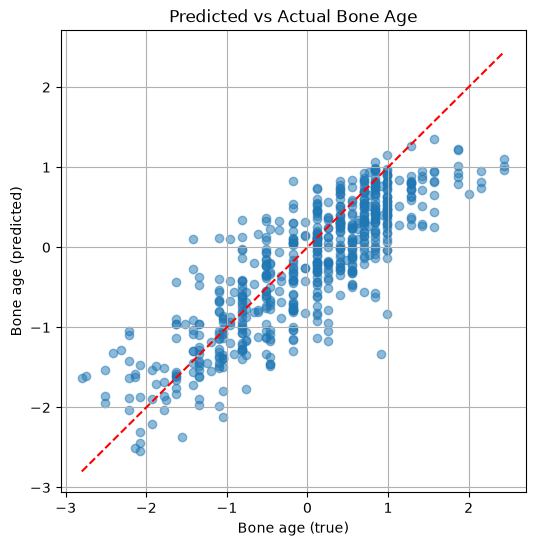

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.5)

plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    'r--'
)

plt.xlabel("Bone age (true)")
plt.ylabel("Bone age (predicted)")
plt.title("Predicted vs Actual Bone Age")

plt.grid(True)
plt.show()

In [26]:
import numpy as np
import torch

def test_mae_months(model, loader, scaler, device="cuda"):
    model.eval()

    y_true = []
    y_pred = []

    mean = scaler.mean_[0]
    std = scaler.scale_[0]

    with torch.no_grad():
        for batch in loader:

            image = batch["image"].to(device)
            male = batch["male"].float().unsqueeze(1).to(device)
            y = batch["boneage"].to(device)

            pred = model(image, male)

            y_true.append(y.detach().cpu().numpy())
            y_pred.append(pred.detach().cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    # inverse transform (standardized -> real months)
    y_true = y_true * std + mean
    y_pred = y_pred * std + mean

    mae = np.mean(np.abs(y_true - y_pred))

    return mae, y_true, y_pred

In [27]:
mae, y_true, y_pred = test_mae_months(model, test_loader, scaler_seg, device="cuda")

print("Test MAE (months):", mae)

Test MAE (months): 20.14258821325132
